# Módulo 1.1 - Python científico

## Este notebook:
* lê arquivo .dat de SAXS, no formato q, I, erro
* calcula o Raio de giro pela aproximação de Guinnier
* cria gráfico I x q
* cria gráfico lnI x q² com ajuste de Guinnier

In [82]:
import numpy as np
import matplotlib.pyplot as plt

In [84]:
#definição do arquivo com os dados no formato correto e variáveis
data = np.loadtxt(r"C:\Users\rawju\OneDrive\Google Drive - USP\Pesquisa\Analise\Analises Mest Doc\SAXS\DadosTratados\bsac14_0.dat")
q, I, err = data[:,0], data[:,1], data[:,2]
q2=q*q
lnI=np.log(I)

### Criando o gráfico da curva de SAXS,intensidade pelo vetor de espalhamento 

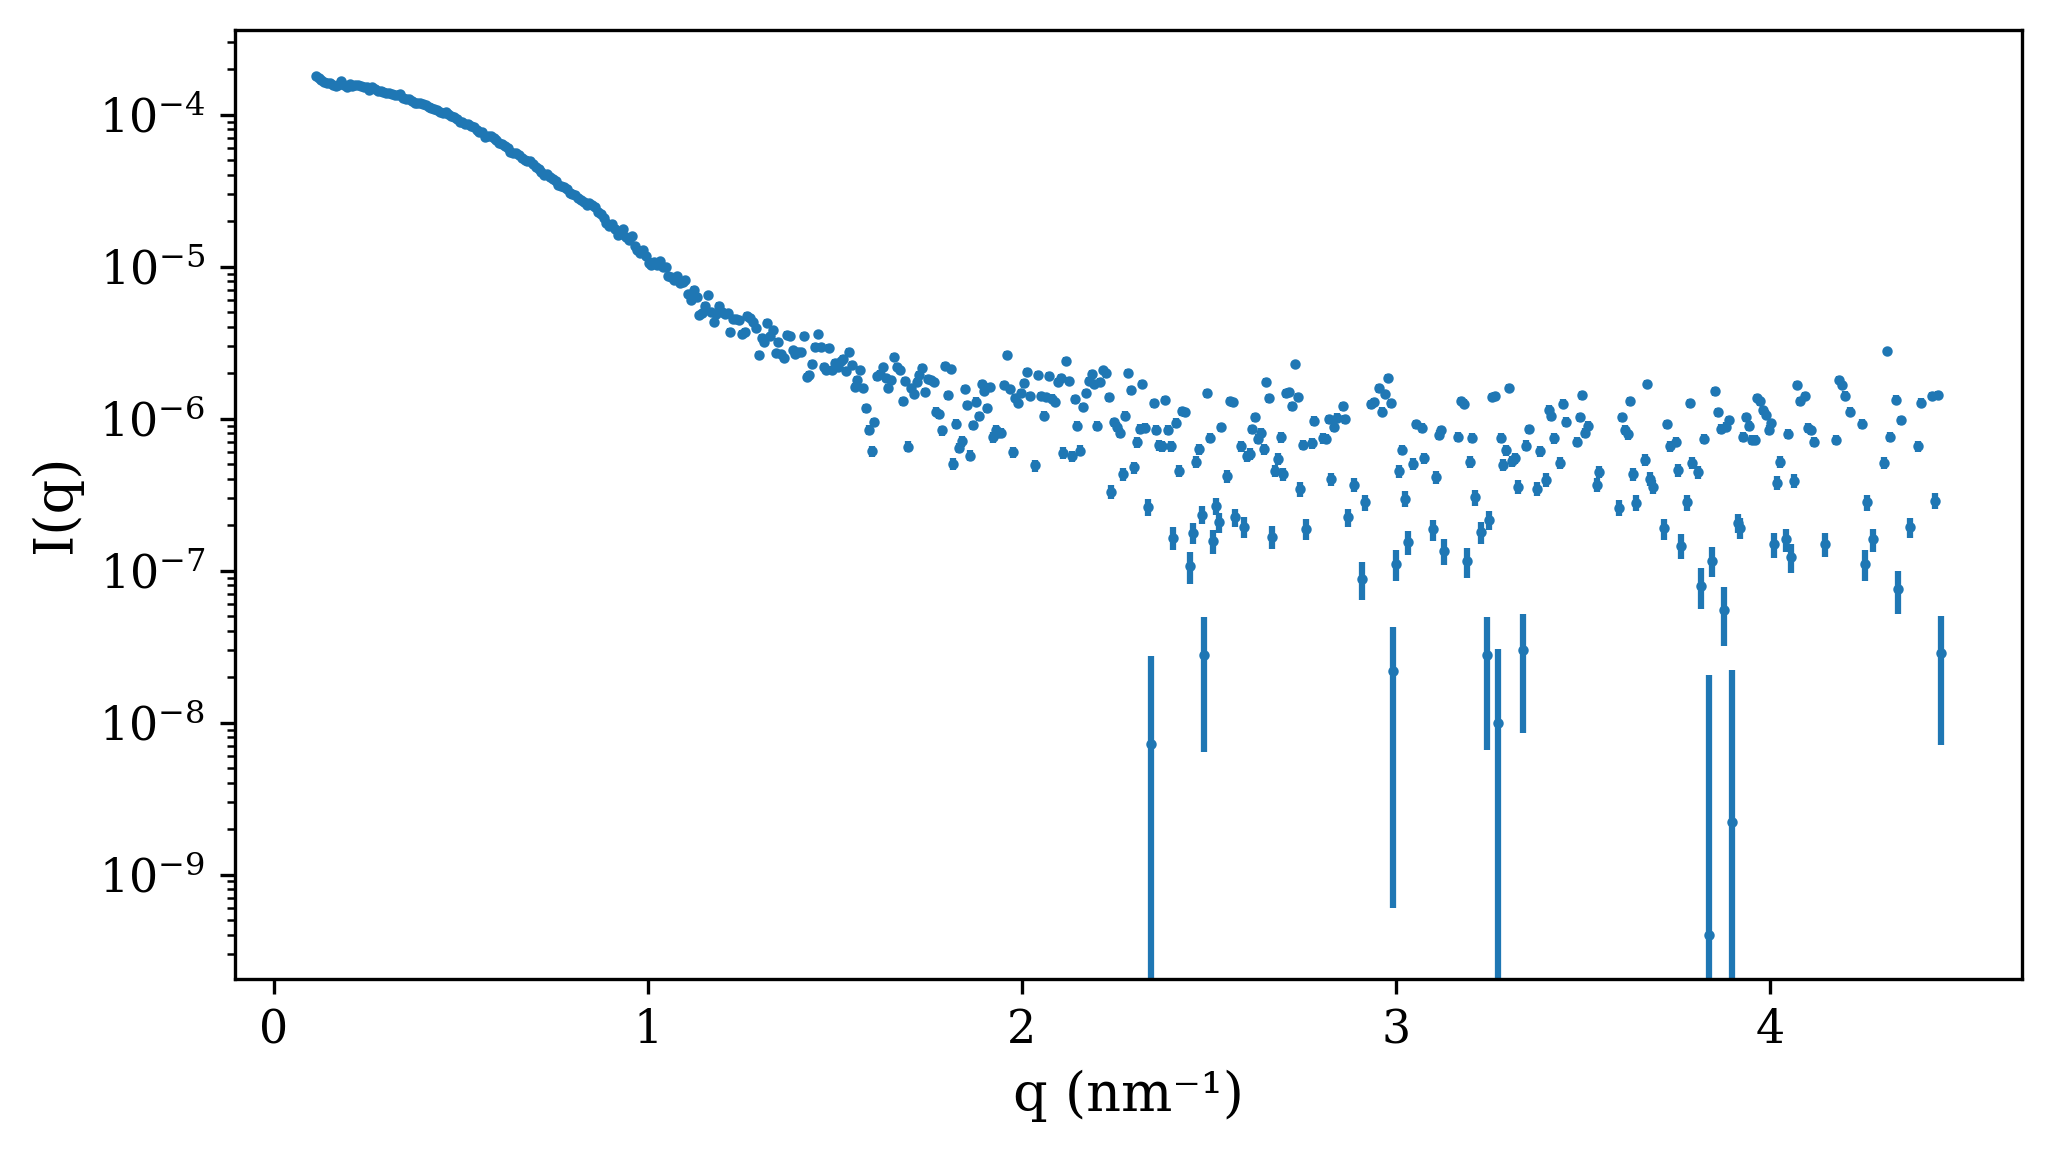

In [76]:
plt.rcParams.update({
      "font.size": 12,
      "font.family": "serif",  # ou "sans-serif" dependendo do journal
      "axes.labelsize": 13,
      "xtick.labelsize": 11,
      "ytick.labelsize": 11,
  })
plt.figure(figsize=(7, 4), dpi=300)
plt.errorbar(q,I,yerr=err,fmt='.',markersize=3)
plt.yscale("log")
plt.xlabel("q (nm⁻¹)")
plt.ylabel("I(q)")
plt.tight_layout()
plt.show()

## Plot de Guinier
O raio de giro será calculado a partir da aproximação de Guinier:
$$I(q) = I(0) \exp{-q^2R_g^2/3}$$
Ao aplicarmos ln nos dois lados da equação temos:
$$\ln I(q) = \ln I(0) - \frac{R_g^2}{3} q^2$$
Com o ajuste de uma reta (lnIxq²) conseguimos calcular o raio de giro a partir do coeficiente angular

***Atenção, a aproxima só é válida no limite do regime de Guinier, onde:*** $q \cdot R_g < 1{,}3$ 

Para defirmos essa região usaremos uma estimativa inicial com poucos pontos

In [77]:
coef_init = np.polyfit(q2[:10], lnI[:10], 1)  # estimativa inicial dos coeficientes primeiros 10 pontos
Rg_init = np.sqrt(-coef_init[0] * 3) # estimativa inicial do raio de giro
print(f"Estimativa inicial do Rg = {Rg_init:.2f} nm")


Estimativa inicial do Rg = 3.90 nm


### Utilizando estimativa inicial para criar uma máscara sobre os dados, obter o ajuste de guinier e o raio de giro

In [78]:
mask = q * Rg_init < 1.3          # array de True/False, um por ponto
q2_guinier = q2[mask]              # só os pontos onde a condição é True
lnI_guinier = lnI[mask]

In [79]:
coef = np.polyfit(q2_guinier, lnI_guinier, 1) #calcula os coeficientes do ajuste de um polinômio de grau 1 dos dados com máscara
Rg = np.sqrt(-coef[0] * 3) #calcula raio de guiro a partir do coeficiente a cima
lnI_fit = np.polyval(coef, q2_guinier) #obtem os pontos do ajuste
print(f"Raio de giro pela aproximação de Guinier Rg = {Rg:.2f} nm")

Raio de giro pela aproximação de Guinier Rg = 2.61 nm


### Criando gráfico de lnIxq² com ajuste de Guinier

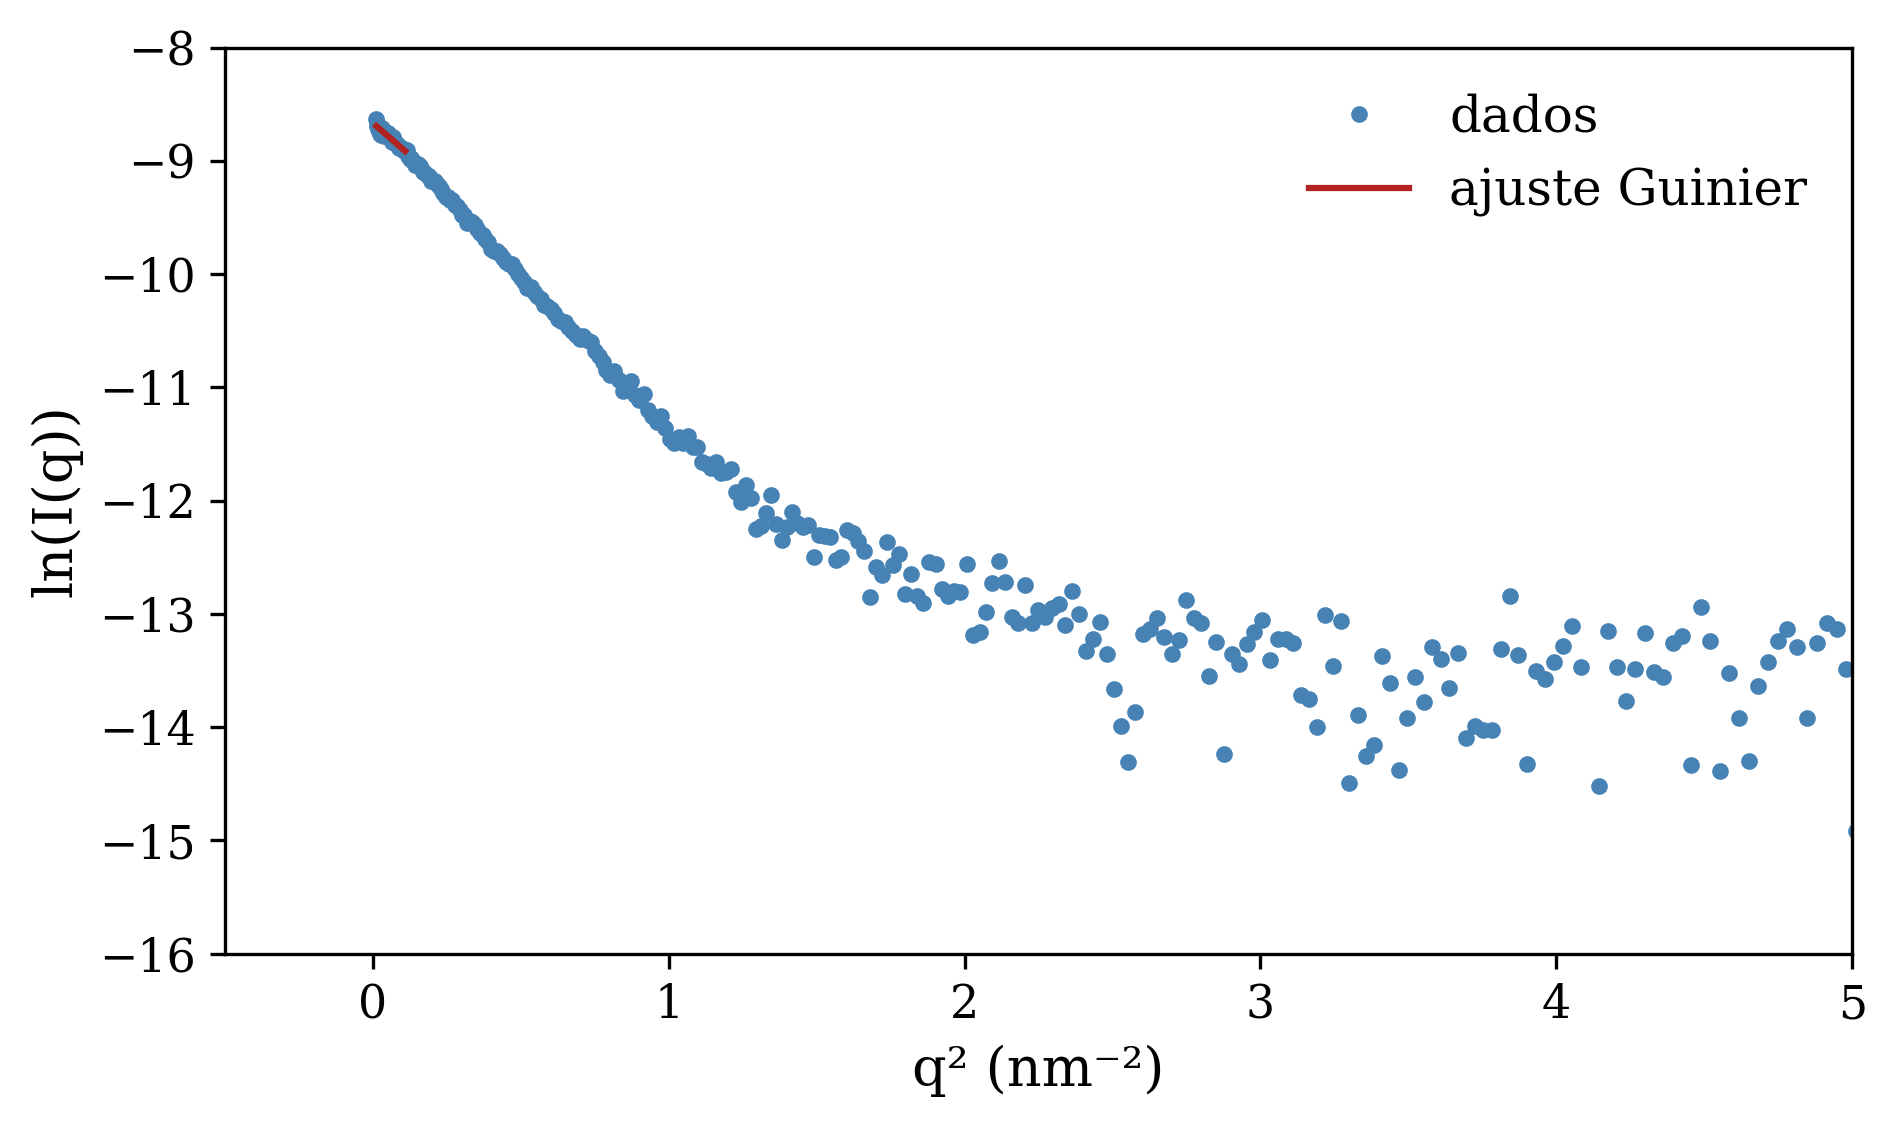

In [83]:
plt.figure(figsize=(7, 4), dpi=300)  # dpi alto para impressão
plt.plot(q*q, lnI, "o", markersize=3, color="steelblue", label="dados")
plt.plot(q2_guinier, lnI_fit, "-", color="firebrick", linewidth=1.5,
label="ajuste Guinier")
plt.legend(frameon=False)  # legenda sem caixa
plt.xlabel("q² (nm⁻²)")
plt.ylabel("ln(I(q))")
plt.xlim(-0.5, 5)
plt.ylim(-16, -8)
plt.show()
#  plt.savefig("guinier.pdf", bbox_inches="tight")   # PDF #  plt.savefig("guinier.png", dpi=300, bbox_inches="tight")  # PNG 